# Accrual Quality (Dechow-Dichev) — a quantitative teardown 🔬
### A point-in-time calendar-time tercile long-short (Newey-West) · a pooled event-drift cross-check with a label-shuffle placebo · an era split · a working-capital-accrual variant · the earnings-persistence mechanism · a 12-seed synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Earnings persistence%3F: Confirmed](https://img.shields.io/badge/Earnings_persistence%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — **low accrual quality is discounted, so long high-quality / short low-quality earns a positive spread** — splits into two testable pieces, and the two give opposite answers. This is distinct from every sibling on the desk: [231](../../231-sloan-accruals/) ranks on the accrual *level*, [522](../../522-percent-operating-accruals/) on accruals scaled by *earnings*, [539](../../539-cash-flow-volatility/) on raw *cash-flow* vol, [52](../../52-smoke-screen/) on *discretionary-accrual manipulation*. This is the **Dechow-Dichev residual volatility** — the reliability of the accrual-to-cash mapping.

> ⚠️ **Data note.** EDGAR `NetIncomeLoss` / `NetCashProvidedByUsedInOperatingActivities` (quarterly flows reconstructed from the YTD cumulative chain) + `Assets` + yfinance adjusted closes, 42 names, ends 2010-10-31 → 2026-03-31, as-of 2026-06-30. Point-in-time on the **filing date** (the DD lead-CFO term never peeks past it). Survivorship named on the Signal axis (current-survivors basket). Thin/uneven coverage is a first-class caveat. Numbers in [`docs/results.md`](../docs/results.md) (prices fingerprint `f0610f2cc06e`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from accrual_quality import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PX, EV = data.load_real()
else:
    PX = EV = None
print("real cache present:", HAVE_REAL, "| events:", (0 if EV is None else len(EV)),
      "| names:", (0 if EV is None else EV['ticker'].nunique()))

# frozen headline numbers (mirror of docs/results.md)
R = {'as_of': '2026-06-30', 'n_names': 42, 'n_events': 2066, 'end_lo': '2010-10-31', 'end_hi': '2026-03-31', 'fp_prices': 'f0610f2cc06e', 'n_months': 182, 'avg_n': 33.5, 'ls_span_lo': '2011-05-31', 'ls_span_hi': '2026-06-30', 'ls_mean_bps': -3.6, 'ls_ann': -0.44, 'ls_t_iid': -0.19, 'ls_t_nw': -0.18, 'ls_sharpe': -0.05, 'ls_hit': 49, 'ls_long_bps': 124.3, 'ls_short_bps': 127.9, 'ls_turn': 0.07, 'ls_cum': 0.88, 'ls120_mean_bps': -6.7, 'ls120_t_nw': -0.33, 'wc_mean_bps': -10.7, 'wc_t_nw': -0.47, 'wc_sharpe': -0.11, 'xsec_early': 25.9, 'xsec_late': 39.7, 'drift': {21: (2066, 1.01, 1.25, -0.24, -0.58, 51, 0.7269), 63: (2038, 3.4, 3.96, -0.56, -0.79, 52, 0.7985), 126: (1999, 7.19, 8.17, -0.98, -0.91, 53, 0.8444)}, 'mono63': (3.96, 3.36, 3.4), 'era_early_n': 80, 'era_early_bps': 0.4, 'era_early_t': 0.02, 'era_late_n': 102, 'era_late_bps': -6.8, 'era_late_t': -0.23, 'p_n': 2066, 'good_slope': 0.87, 'good_t': 19.97, 'poor_slope': 0.273, 'poor_t': 8.59, 'slope_gap': 0.596, 'good_earn_vol': 0.53, 'poor_earn_vol': 2.44, 'net': {(10, 50): (-9.2, -1.1, -0.46, -0.12), (20, 100): (-14.7, -1.77, -0.73, -0.2)}, 'syn_null_mean': 0.1, 'syn_null_sd': 1.08, 'syn_null_fire': 1, 'syn_null_seeds': 12, 'syn_planted_bps': 982.0, 'syn_planted_t': 23.79}


real cache present: True | events: 2066 | names: 42


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** (returns) | `NONE` | calendar tercile long-short **-3.6 bps/mo** (-0.4%/yr gross), one-sample *t* = -0.19, **Newey-West *t* = -0.18**; WC-accrual variant NW *t* = -0.47 — zero, faintly wrong-signed |
| **Tradability** | `MIRAGE` | net of 20 bps + 100 bps borrow: NW *t* = -0.73, Sharpe -0.20; wrong-signed **before** costs |
| **Flags earnings quality?** | `CONFIRMED` | persistence slope **+0.87** (high-Q) vs **+0.27** (low-Q); earnings vol **0.5%** vs **2.4%** of assets |

> 💡 In plain words: the accounting construct is bulletproof and the return edge is a flat null (leaning faintly the wrong way). A public earnings-quality number sorts the business, and the market has already priced the stocks accordingly.

## 1 · The claim, steelmanned

Let $a_{i,q} = (NI_{i,q} - CFO_{i,q})/\overline{TA}$ be name $i$'s asset-scaled accrual at fiscal quarter $q$ and $x_{i,q} = CFO_{i,q}/\overline{TA}$. The Dechow-Dichev regression over a rolling window is

$$a_{i,t} = \alpha + \beta_1 x_{i,t-1} + \beta_2 x_{i,t} + \beta_3 x_{i,t+1} + \varepsilon_{i,t},$$

and **accrual quality** is $\sigma(\hat\varepsilon)$ over the window (a *high* residual vol = *poor* quality). The signal `quality` $= -\sigma(\hat\varepsilon)$, known at $q$'s filing (the window only uses $t \le q-1$, so the lead term $x_{t+1}=x_q$ is public — no look-ahead). The claims:

- **H₁ (flags earnings quality).** Low quality ⇒ less-persistent, noisier earnings — the DD validity mechanism.
- **H₂ (priced discount).** A cross-sectional long-short on `quality` earns a positive forward return spread — the retail mispricing claim.
- **H₃ (tradable).** That spread survives realistic long-short costs + borrow.

We find **H₁ strongly supported** (persistence +0.87 vs +0.27, earnings vol 0.5% vs 2.4%), **H₂ not supported** (NW *t* = -0.18, flat non-monotone drift, *faintly wrong-signed*), and therefore **H₃ moot**. Note the sign: Francis, LaFond, Olsson & Schipper (2005) argue poor accrual quality earns a **risk premium** (low quality → *higher* return), the opposite of the discount claim — and our sliver of tilt is on *that* side. Either way it is a null, so the honest stamp is `NONE`, not a rescued `WEAK`.

## 2 · So what? — inference design

The primary is a **calendar-time** long-short, not a pooled event study, precisely because balance-sheet quality signals are persistent and filings cluster: a calendar series of monthly long-short returns lets a **Newey-West (6-lag) HAC *t*** do the honest work the desk's `REAL` bar is written against. The panel is thin, so we sort into **terciles** (not quintiles) and require ≥ 6 names in the cross-section. The pooled event drift + a **label-shuffle placebo** is the cross-check; the earnings-persistence axis is graded on **magnitude** (its pooled *t* ignores quarter clustering, so we read the +0.87-vs-+0.27 slope gap and the 5× vol gap, not the literal *t*).

## 3 · How we'd know — the protocol

- **Panel.** 2,066 (ticker, filing) accrual-quality quarters across 42 names, ends 2010-10-31 → 2026-03-31, each stamped with its 10-Q/10-K filing date (point-in-time; quarterly flows reconstructed from the YTD cumulative chain).
- **Primary.** Monthly tercile long-short on `quality`, one execution lag (rank at month $M$ close, earn month $M{+}1$); Newey-West + one-sample *t*, Sharpe, hit rate.
- **Cross-check.** Pooled event drift over 21/63/126 trading days, one-day-lag entry, top-minus-bottom tercile, one-sample *t* + 10k-draw label-shuffle placebo, and the tercile monotonicity picture.
- **Robustness.** Staleness 120 vs 200 days; the working-capital-accrual variant (residual vol of `(ΔReceivables+ΔInventory)/avg-assets`); an era split at 2018.
- **Mechanism.** ROA persistence slope (next-q ROA on ROA) and earnings volatility, best- vs worst-quality tercile.
- **Execution.** Long-short net of one-way cost × turnover (both legs) + short borrow.
- **Control.** Synthetic panel, planted-relation knob; the null must not fire across 12 seeds.

## 4 · The teardown

### 4a · The primary — calendar-time tercile long-short (Newey-West)

Rank fresh `quality` into terciles each month, long top (high quality) / short bottom equal-weight, earn next month's return. The decisive statistic is the HAC *t* of the monthly long-short series.

calendar long-short: -3.6 bps/mo (-0.44%/yr gross), n=182 months, avg cross-section 33.5
  one-sample t = -0.19   Newey-West(6) t = -0.18   Sharpe -0.05   hit 49%   turnover 0.07
  WC-accrual variant: -10.7 bps/mo, NW t = -0.47, Sharpe -0.11


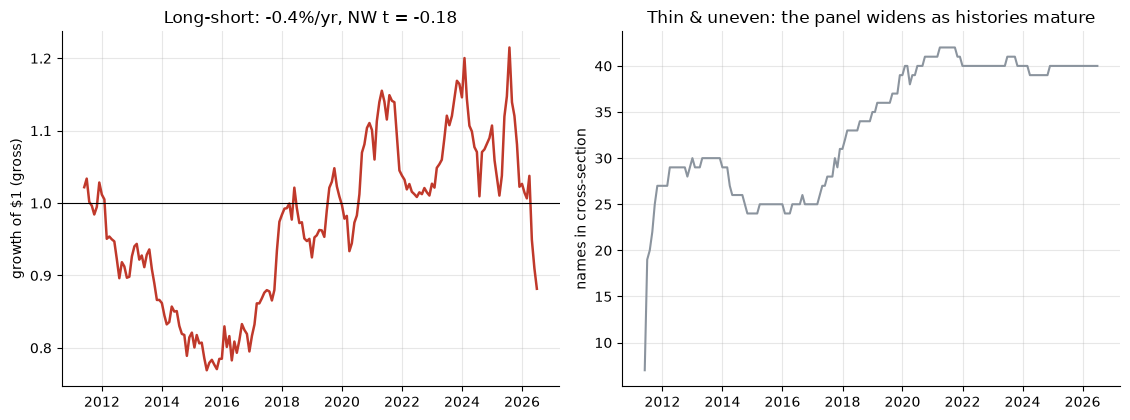

frozen: -3.6 bps/mo, NW t = -0.18, staleness-120 NW t = -0.33, WC-accrual NW t = -0.47


In [2]:
if HAVE_REAL:
    ls = st.calendar_ls(PX, EV, signal_col='quality', n_buckets=3, min_names=6, staleness_days=200)
    s = st.calendar_ls_stats(ls)
    ev_wc = EV.copy(); ev_wc['quality_wc'] = -ev_wc['aq_vol_wc']
    ls_wc = st.calendar_ls(PX, ev_wc, signal_col='quality_wc', n_buckets=3, min_names=6, staleness_days=200)
    s_wc = st.calendar_ls_stats(ls_wc)
    print(f"calendar long-short: {s['mean_bps']:+.1f} bps/mo ({s['ann_pct']:+.2f}%/yr gross), "
          f"n={s['n_months']} months, avg cross-section {s['avg_n']:.1f}")
    print(f"  one-sample t = {s['t_iid']:+.2f}   Newey-West(6) t = {s['t_nw']:+.2f}   "
          f"Sharpe {s['sharpe']:.2f}   hit {s['hit']*100:.0f}%   turnover {s['avg_turnover']:.2f}")
    print(f"  WC-accrual variant: {s_wc['mean_bps']:+.1f} bps/mo, NW t = {s_wc['t_nw']:+.2f}, Sharpe {s_wc['sharpe']:.2f}")
    cum = (1+ls['ls']).cumprod(); nser = ls['n']
else:
    cum = None; nser = None
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.4, 4.3))
if cum is not None:
    a1.plot(cum.index, cum.values, color=RED, lw=1.8); a1.axhline(1, c='k', lw=.8)
    a1.set_ylabel('growth of $1 (gross)'); a1.set_title(f"Long-short: {R['ls_ann']:+.1f}%/yr, NW t = {R['ls_t_nw']:+.2f}")
    a2.plot(nser.index, nser.values, color=GREY, lw=1.5); a2.set_ylabel('names in cross-section')
    a2.set_title('Thin & uneven: the panel widens as histories mature')
else:
    for a in (a1,a2): a.text(.5,.5,'run with cache',ha='center'); a.set_axis_off()
plt.tight_layout(); plt.show()
print(f"frozen: {R['ls_mean_bps']:+.1f} bps/mo, NW t = {R['ls_t_nw']:+.2f}, "
      f"staleness-120 NW t = {R['ls120_t_nw']:+.2f}, WC-accrual NW t = {R['wc_t_nw']:+.2f}")

> 💡 In plain words: **-4 bps/month** is economically nothing (-0.4%/yr gross), and the HAC *t* is **-0.18** — on the wrong side of zero. Every specification agrees: staleness-120 NW *t* = -0.33, the working-capital-accrual variant NW *t* = -0.47. There is no positive quality premium in these returns — the book grew \$1 into \$0.88 over 182 months.

### 4b · The cross-check — pooled event drift + placebo + monotonicity

Bucket all events by `quality`; top-minus-bottom (high-Q minus low-Q) forward drift with a label-shuffle null. If there were a sort, the terciles would form a ladder.

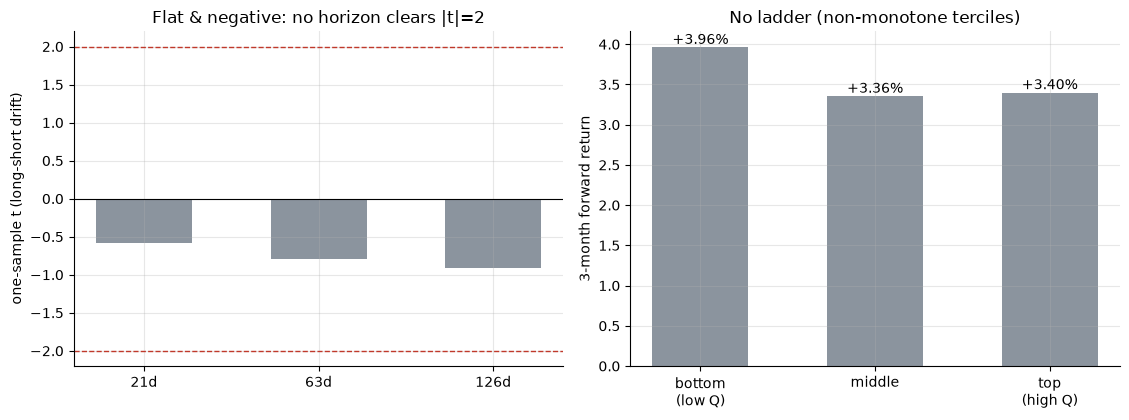

  H= 21d: long-short -0.24%  t=-0.58  win=51%  placebo p=0.725
  H= 63d: long-short -0.56%  t=-0.79  win=52%  placebo p=0.800
  H=126d: long-short -0.98%  t=-0.91  win=53%  placebo p=0.850


In [3]:
rows = []
if HAVE_REAL:
    for h in st.HORIZONS:
        es = st.event_summary(PX, EV, horizon=h, n_buckets=3, n_draws=4000)
        rows.append((h, es['ls_mean']*100, es['t'], es['ls_win']*100, es['p_placebo']))
    mono = st.bucket_means(st.event_drift_frame(PX, EV, horizon=63), 3)*100
else:
    for h in st.HORIZONS:
        d = R['drift'][h]; rows.append((h, d[3], d[4], d[5], d[6]))
    mono = np.array(R['mono63'])
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.4, 4.3))
hs = [r[0] for r in rows]; ts = [r[2] for r in rows]
a1.bar([f'{h}d' for h in hs], ts, color=GREY, width=.55)
a1.axhline(2, ls='--', c=RED, lw=1); a1.axhline(-2, ls='--', c=RED, lw=1); a1.axhline(0, c='k', lw=.8)
a1.set_ylabel('one-sample t (long-short drift)'); a1.set_title('Flat & negative: no horizon clears |t|=2')
a2.bar(['bottom\n(low Q)','middle','top\n(high Q)'], mono, color=GREY, width=.55)
for i,v in enumerate(mono): a2.annotate(f'{v:+.2f}%',(i,v),ha='center',va='bottom')
a2.set_ylabel('3-month forward return'); a2.set_title('No ladder (non-monotone terciles)')
plt.tight_layout(); plt.show()
for h,ls_,t,win,p in rows:
    print(f'  H={h:>3}d: long-short {ls_:+.2f}%  t={t:+.2f}  win={win:.0f}%  placebo p={p:.3f}')

> 💡 In plain words: the pooled long-short drift is **negative at every horizon** (*t* from -0.58 to -0.91), the label-shuffle placebo *p* sits at **0.73-0.84** (the observed sits in the *left* tail — a random tercile split beats buying quality most of the time), and the terciles are **non-monotone** (+3.96% / +3.36% / +3.40% low→high at 63d). The event study and the calendar long-short agree: no positive return sort — if anything a faint negative one.

### 4c · Era split — nothing hiding in a regime

Split the calendar long-short at 2018.

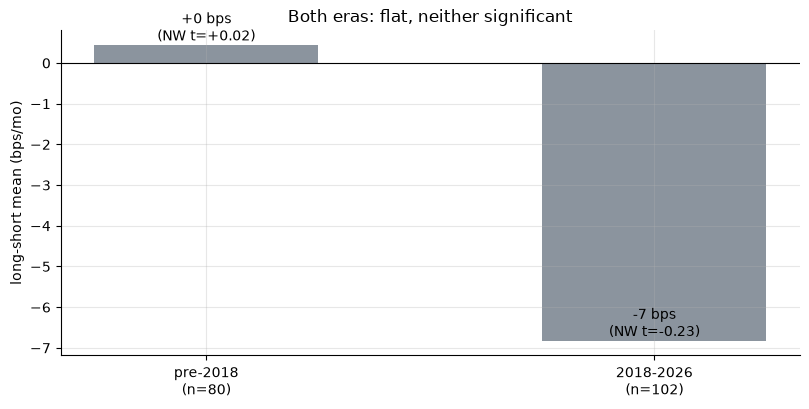

pre-2018: +0.4 bps NW t=+0.02 (n=80)  |  2018-2026: -6.8 bps NW t=-0.23 (n=102)


In [4]:
if HAVE_REAL:
    e = ls[ls.index < '2018-01-01']['ls'].to_numpy(); l = ls[ls.index >= '2018-01-01']['ls'].to_numpy()
    eb, et, en = e.mean()*1e4, st.newey_west_t(e), len(e)
    lb, lt, ln = l.mean()*1e4, st.newey_west_t(l), len(l)
else:
    eb, et, en = R['era_early_bps'], R['era_early_t'], R['era_early_n']
    lb, lt, ln = R['era_late_bps'], R['era_late_t'], R['era_late_n']
fig, ax = plt.subplots(figsize=(8.2, 4.2))
ax.bar([f'pre-2018\n(n={en})', f'2018-2026\n(n={ln})'], [eb, lb], color=[GREY, GREY], width=.5)
for i,(v,t_) in enumerate([(eb,et),(lb,lt)]): ax.annotate(f'{v:+.0f} bps\n(NW t={t_:+.2f})',(i,v),ha='center',va='bottom')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('long-short mean (bps/mo)')
ax.set_title('Both eras: flat, neither significant')
plt.tight_layout(); plt.show()
print(f'pre-2018: {eb:+.1f} bps NW t={et:+.2f} (n={en})  |  2018-2026: {lb:+.1f} bps NW t={lt:+.2f} (n={ln})')

> 💡 In plain words: +0 bps (NW *t* = +0.02) pre-2018, -7 bps (NW *t* = -0.23) after — dead flat early, faintly negative late. It was never a live edge; there is nothing to decay.

### 4d · The mechanism — accrual quality *does* flag earnings quality

The DD validity claim: split into quality terciles, compare the ROA persistence slope (next-q ROA on ROA) and the earnings volatility of the best vs worst tercile.

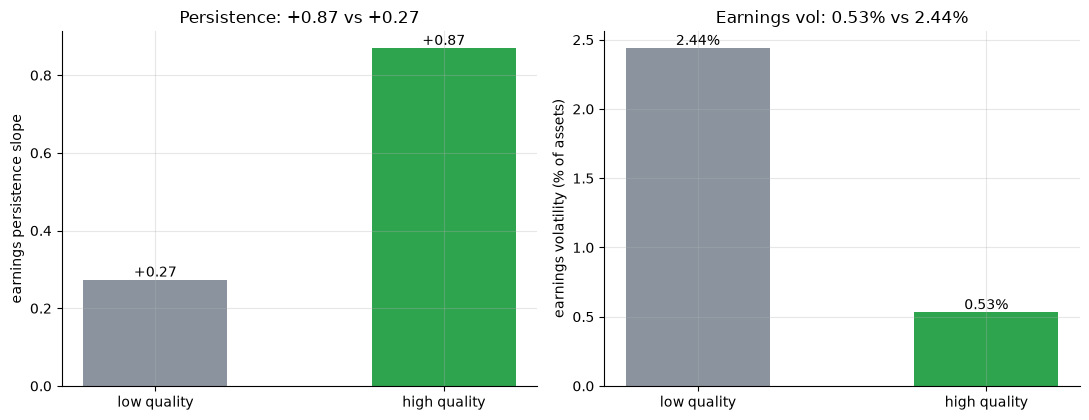

persistence: high-Q +0.870 vs low-Q +0.273 (gap +0.596)  |  earnings vol: high-Q 0.53% vs low-Q 2.44% of assets


In [5]:
if HAVE_REAL:
    q = st.persistence_by_quality(EV)
    gs, ps = q['good_slope'], q['poor_slope']
    gev, pev = q['good_earn_vol']*100, q['poor_earn_vol']*100
else:
    gs, ps = R['good_slope'], R['poor_slope']
    gev, pev = R['good_earn_vol'], R['poor_earn_vol']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.3))
a1.bar(['low quality','high quality'], [ps, gs], color=[GREY, GREEN], width=.5)
for i,v in enumerate([ps, gs]): a1.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom')
a1.set_ylabel('earnings persistence slope'); a1.set_title(f'Persistence: +{gs:.2f} vs +{ps:.2f}')
a2.bar(['low quality','high quality'], [pev, gev], color=[GREY, GREEN], width=.5)
for i,v in enumerate([pev, gev]): a2.annotate(f'{v:.2f}%',(i,v),ha='center',va='bottom')
a2.set_ylabel('earnings volatility (% of assets)'); a2.set_title(f'Earnings vol: {gev:.2f}% vs {pev:.2f}%')
plt.tight_layout(); plt.show()
print(f'persistence: high-Q {gs:+.3f} vs low-Q {ps:+.3f} (gap {gs-ps:+.3f})  |  '
      f'earnings vol: high-Q {gev:.2f}% vs low-Q {pev:.2f}% of assets')

> 💡 In plain words: this is the study's one unambiguous result — high accrual quality **means more persistent, less volatile earnings**, with a persistence gap of **+0.60** (+0.87 vs +0.27) and ~5× lower earnings volatility (0.5% vs 2.4% of assets). The Dechow-Dichev construct is exactly as advertised. The return null is therefore not a data problem — it's a **market-efficiency** result: earnings-quality is a public, slow-moving fundamental the market already prices. (The persistence *t*'s are pooled across clustered filings; we cite the magnitude, not the *t*.)

### 4e · Tradability — the timer

For completeness, the calendar long-short net of one-way costs × turnover (both legs) + short borrow — though a wrong-signed gross *t* already settles it.

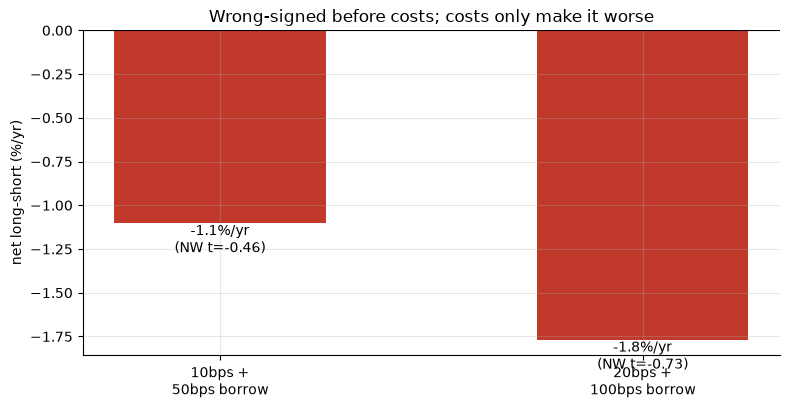

  cost 10bps + borrow 50bps/yr: -1.10%/yr net, NW t=-0.46, Sharpe -0.12
  cost 20bps + borrow 100bps/yr: -1.77%/yr net, NW t=-0.73, Sharpe -0.20


In [6]:
rows = []
if HAVE_REAL:
    for cb, bb in [(10.0,50.0),(20.0,100.0)]:
        nt = st.calendar_ls_net(ls, cost_bps=cb, borrow_bps_ann=bb)
        rows.append((cb, bb, nt['net_ann_pct'], nt['net_t_nw'], nt['net_sharpe']))
else:
    for (cb,bb),v in R['net'].items(): rows.append((cb, bb, v[1], v[2], v[3]))
labels = [f'{int(cb)}bps +\n{int(bb)}bps borrow' for cb,bb,_,_,_ in rows]
anns = [r[2] for r in rows]
fig, ax = plt.subplots(figsize=(8.0, 4.2))
ax.bar(labels, anns, color=[RED, RED], width=.5)
for i,(cb,bb,a,t,sh) in enumerate(rows): ax.annotate(f'{a:+.1f}%/yr\n(NW t={t:+.2f})',(i,a),ha='center',va='top')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('net long-short (%/yr)')
ax.set_title('Wrong-signed before costs; costs only make it worse')
plt.tight_layout(); plt.show()
for cb,bb,a,t,sh in rows: print(f'  cost {int(cb)}bps + borrow {int(bb)}bps/yr: {a:+.2f}%/yr net, NW t={t:+.2f}, Sharpe {sh:.2f}')

> 💡 In plain words: turnover is low (~0.07/mo — a slow quarterly balance-sheet signal), but it doesn't matter: the gross spread was already wrong-signed and insignificant, so costs just push net to -1.8%/yr (NW *t* = -0.73). **Tradability = MIRAGE.**

### 4f · Faithful-engine & power control

Synthetic price + quality panel with a TUNABLE planted relation (high-quality names drift up). The null (edge = 0) is checked over **12 seeds**.

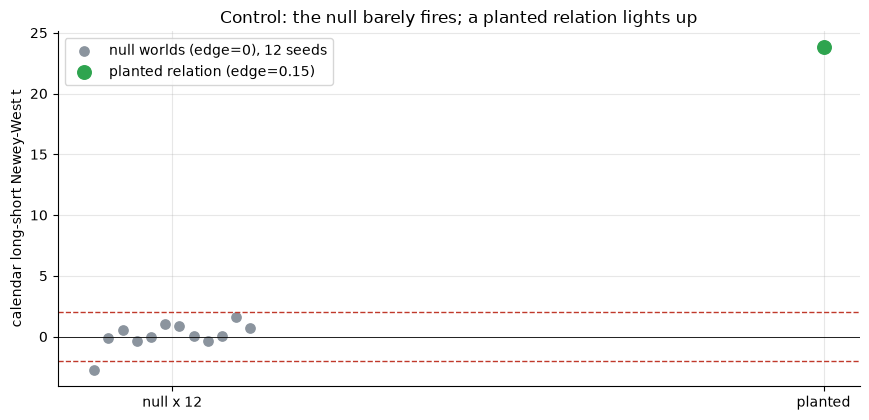

null: mean NW t = +0.10 (sd 1.08), |t|>=2 in 1/12  |  planted NW t = +23.79


In [7]:
null_ts = []
for s_ in range(12):
    p0, e0 = data.synthetic_panel(edge=0.0, seed=855 + s_)
    null_ts.append(st.synthetic_detect(p0, e0)['t_nw'])
null_ts = np.asarray(null_ts)
p1, e1 = data.synthetic_panel(edge=0.15, seed=855)
planted_t = st.synthetic_detect(p1, e1)['t_nw']
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.linspace(-.12,.12,12), null_ts, color=GREY, s=45, label='null worlds (edge=0), 12 seeds')
ax.scatter([1], [planted_t], color=GREEN, s=95, zorder=5, label='planted relation (edge=0.15)')
ax.axhline(2, ls='--', c=RED, lw=1); ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(0, c='k', lw=.6)
ax.set_xticks([0,1]); ax.set_xticklabels(['null x 12','planted'])
ax.set_ylabel('calendar long-short Newey-West t')
ax.set_title('Control: the null barely fires; a planted relation lights up'); ax.legend()
plt.tight_layout(); plt.show()
print(f'null: mean NW t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_ts)>=2).sum()}/12  |  planted NW t = {planted_t:+.2f}')

> 💡 In plain words: across 12 null worlds the detector averages NW *t* = +0.10 (sd 1.08) and crosses |t|=2 only 1/12 times — about what chance gives you for a HAC *t* over ~180 months. A planted relation reads NW *t* = 23.8. The machinery is unbiased and powered, so the real-tape -0.18 is a genuine null, not a broken pipeline. *(Power check only — never cited in support of a real-tape stamp.)*

## 5 · The verdict

- **Signal (returns) `NONE`** — calendar tercile long-short -3.6 bps/mo (-0.4%/yr gross), one-sample *t* = -0.19, **Newey-West *t* = -0.18**; WC-accrual variant NW *t* = -0.47; pooled event drift negative and non-monotone at every horizon (placebo *p* 0.73-0.84); both eras flat. Zero, faintly wrong-signed — the desk's `NONE`.
- **Tradability `MIRAGE`** — net of 20 bps + 100 bps borrow: -1.77%/yr, NW *t* = -0.73, Sharpe -0.20; wrong-signed before costs.
- **Flags earnings quality? `CONFIRMED`** — persistence +0.87 vs +0.27, earnings vol 0.5% vs 2.4%. The construct is real; the market prices it.

## 6 · Going further

- **The direction worth chasing** is the *information-risk premium*, not the *discount*: Francis et al. (2005) find poor accrual quality earns a **higher** cost of capital — the opposite of the retail pitch — and the faint wrong-signed tilt here is on that side. A public fundamental that grades the business but not the stock is the textbook signature of an efficiently-priced characteristic; any alpha lives in the part the market can't already see.
- **Coverage honesty:** the rolling 12-quarter window needs ~4 years of clean quarterly cash-flow history first, and the cross-section runs from ≈26 names (2012) to ≈40 (2024+); terciles on a thin early cross-section are noisy, and the flat event drift across 2,000+ pooled events is the more decisive evidence of the return null.
- **Dedup map:** [231-sloan-accruals](../../231-sloan-accruals/) (the accrual *level/sign*), [522-percent-operating-accruals](../../522-percent-operating-accruals/) (accruals scaled by earnings), [539-cash-flow-volatility](../../539-cash-flow-volatility/) (raw cash-flow vol — DD nets exactly this out), [52-smoke-screen](../../52-smoke-screen/) (discretionary-accrual manipulation). None ranks on the DD residual volatility itself.

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*